In [ ]:
# Install the ultralytics package from GitHub
#!pip install git+https://github.com/ultralytics/ultralytics.git@main

  Cloning https://github.com/ultralytics/ultralytics.git (to revision main) to /tmp/pip-req-build-biq0qfip
  Running command git clone --filter=blob:none --quiet https://github.com/ultralytics/ultralytics.git /tmp/pip-req-build-biq0qfip
  Resolved https://github.com/ultralytics/ultralytics.git to commit 4812bdfcabd894cab15c05bcd7c1187730d8ba10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the YOLO model
#model = YOLO("yolov8n.pt")  # You can choose other YOLO versions (e.g., yolov8s, yolov8m)

#https://github.com/derronqi/yolov8-face?tab=readme-ov-file
#https://drive.google.com/file/d/1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb/view
folder = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/train12/weights/"
model = "best.pt"
model_path = folder + model
model = YOLO(model_path)

In [ ]:
import os

# Chemin du dossier
#folder = "/content/drive/MyDrive/Cours_Traitement_Image_Automatique_Option_ENC_2026/Sand"
folder = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/images/"
# Extensions des fichiers images à considérer
image_extensions = (".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".gif")

# Liste uniquement les fichiers image qui ne commencent pas par un point
files = [
    f for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f))
    and f.lower().endswith(image_extensions)
    and not f.startswith(".")
]

# Affiche le nombre de fichiers image valides
print("Number of valid image files:")
print(len(files))



Number of valid image files:
48


In [ ]:
file = files[25]
painting_path = os.path.join(folder, file)
image = cv2.imread(painting_path)
plt.figure(figsize=(20, 16))  # Ajustez la taille en pouces (largeur, hauteur)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Perform face detection
# Setting image_size=None ensures the model processes the original image size
# Get the original dimensions of the image
original_height, original_width = image.shape[:2]

# Perform face detection on the full-resolution image
results = model.predict(image, imgsz=[original_width, original_height])  # Explicitly set the image size



WARNING ⚠️ imgsz=[3172, 2000] must be multiple of max stride 32, updating to [3200, 2016]
0: 1280x2016 4 faces, 31.2ms
Speed: 33.3ms preprocess, 31.2ms inference, 1.7ms postprocess per image at shape (1, 3, 1280, 2016)


In [ ]:
# Visualize results
annotated_frame = results[0].plot()

plt.figure(figsize=(20, 16))  # Ajustez la taille en pouces (largeur, hauteur)
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def show_zoomed_face_kps(image_bgr, results, det_i=0, margin=40, figsize=(4,4)):
    """
    Zoom sur un visage détecté avec affichage des keypoints indexés.
    margin = pixels ajoutés autour de la bounding box
    """
    img_h, img_w = image_bgr.shape[:2]

    # Bounding box
    box = results[0].boxes.xyxy[det_i].cpu().numpy()
    x1, y1, x2, y2 = box

    # Ajout d'une marge et clipping
    x1 = int(max(0, x1 - margin))
    y1 = int(max(0, y1 - margin))
    x2 = int(min(img_w, x2 + margin))
    y2 = int(min(img_h, y2 + margin))

    crop = image_bgr[y1:y2, x1:x2].copy()
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # Keypoints
    kps = results[0].keypoints.data[det_i].cpu().numpy()

    plt.figure(figsize=figsize)
    plt.imshow(crop_rgb)

    for j, (x, y, c) in enumerate(kps):
        # Coordonnées relatives au crop
        xr = x - x1
        yr = y - y1
        plt.scatter([xr], [yr], s=80)
        plt.text(xr + 3, yr - 3, f"{j} ({c:.2f})", fontsize=11)

    plt.title(f"Face #{det_i} (zoom)")
    plt.axis("off")
    plt.show()



0: 416x640 7 faces, 45.3ms
Speed: 8.2ms preprocess, 45.3ms inference, 10.9ms postprocess per image at shape (1, 3, 416, 640)


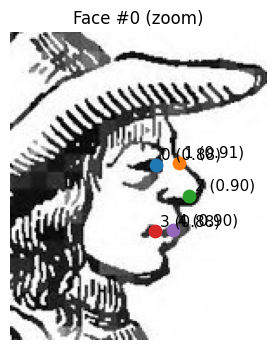

In [ ]:


img = cv2.imread(painting_path)
res = model(img)

show_zoomed_face_kps(img, res, det_i=0)   # un visage



In [ ]:
import cv2

KP_NAMES = ["left_eye", "right_eye", "nose", "left_mouth", "right_mouth"]

def draw_kps(img, results, det_i=0):
    out = img.copy()
    kps = results[0].keypoints.data[det_i].cpu().numpy()  # shape (5,3) généralement: x,y,conf
    for j, (x, y, c) in enumerate(kps):
        x, y = int(x), int(y)
        cv2.circle(out, (x, y), 3, (0, 255, 0), -1)
        cv2.putText(out, f"{j}:{KP_NAMES[j]}", (x+4, y-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1, cv2.LINE_AA)
    return out

file = files[1]
painting_path = os.path.join(folder, file)

img_bgr = cv2.imread(painting_path)
res = model(img_bgr)
vis = draw_kps(img_bgr, res, det_i=0)
cv2.imwrite("debug_kps.jpg", vis)
results[0].keypoints.data[0]


0: 416x640 7 faces, 14.0ms
Speed: 4.8ms preprocess, 14.0ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 640)


tensor([[1.3508e+03, 1.2214e+02, 8.9207e-01],
        [1.3679e+03, 1.1945e+02, 8.8995e-01],
        [1.3780e+03, 1.3916e+02, 8.9536e-01],
        [1.3592e+03, 1.6544e+02, 9.0523e-01],
        [1.3717e+03, 1.6372e+02, 9.0621e-01]], device='cuda:0')

In [ ]:
import json
import os
from pathlib import Path
from PIL import Image

# ========= PARAMÈTRES =========
"/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/annotations_litt.json"

LS_JSON = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/annotations_litt.json"
# export Label Studio
IMAGES_DIR = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/images"    # images copiées depuis Drive
OUT_DIR = "/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose"       # dossier de sortie YOLO
# ==============================


KPT_ORDER = ["right_eye", "left_eye", "nose", "right_mouth", "left_mouth"]
CLASS_ID = 0  # une seule classe : face

def strip_prefix(filename):
    return filename.split("-", 1)[1] if "-" in filename else filename

def rect_to_yolo(value, W, H):
    x = value["x"] / 100.0 * W
    y = value["y"] / 100.0 * H
    w = value["width"] / 100.0 * W
    h = value["height"] / 100.0 * H
    xc = (x + w / 2) / W
    yc = (y + h / 2) / H
    return xc, yc, w / W, h / H

def kp_to_yolo(value):
    return value["x"] / 100.0, value["y"] / 100.0, 2  # visibilité = 2


In [ ]:
data = json.loads(Path(LS_JSON).read_text())

img_out = Path(OUT_DIR) / "images/train"
lbl_out = Path(OUT_DIR) / "labels/train"
img_out.mkdir(parents=True, exist_ok=True)
lbl_out.mkdir(parents=True, exist_ok=True)

In [ ]:
for task in data:
    if not task.get("annotations"):
        continue

    ls_img_name = os.path.basename(task["data"]["image"])
    img_name = strip_prefix(ls_img_name)

    src_img_path = Path(IMAGES_DIR) / img_name
    if not src_img_path.exists():
        print("❌ Image non trouvée:", img_name)
        continue

    W, H = Image.open(src_img_path).size
    results = task["annotations"][0]["result"]

    bboxes = {}
    keypoints = {}
    print(src_img_path)
    print(results)

    for r in results:
        if r["type"] == "rectanglelabels":
            bboxes[r["id"]] = rect_to_yolo(r["value"], W, H)

        elif r["type"] == "keypointlabels":
            parent = r["parentID"]
            label = r["value"]["keypointlabels"][0]
            keypoints.setdefault(parent, {})[label] = kp_to_yolo(r["value"])

    lines = []
    for bbox_id, (xc, yc, w, h) in bboxes.items():
        kp_map = keypoints.get(bbox_id, {})
        flat = []
        for lab in KPT_ORDER:
            flat += list(kp_map.get(lab, (0.0, 0.0, 0)))
        line = [CLASS_ID, xc, yc, w, h] + flat
        lines.append(" ".join(f"{x:.6f}" for x in line))

    if lines:
        dst_img = img_out / img_name
        dst_lbl = lbl_out / (Path(img_name).stem + ".txt")
        dst_img.write_bytes(src_img_path.read_bytes())
        dst_lbl.write_text("\n".join(lines) + "\n")

print("Conversion terminée ! Dataset YOLO prêt dans :", OUT_DIR)


/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/images/Sophie_0.jpg
[{'id': '4PdyfQHBXD', 'type': 'keypointlabels', 'value': {'x': 40.88608957795003, 'y': 38.18621768442627, 'width': 0.2637812230835486, 'keypointlabels': ['right_eye']}, 'origin': 'manual', 'to_name': 'image', 'parentID': 'ER6iMtkyS0', 'from_name': 'keypoints', 'image_rotation': 0, 'original_width': 960, 'original_height': 1470}, {'id': '6GzOTNhoUX', 'type': 'keypointlabels', 'value': {'x': 43.43540404487879, 'y': 38.43554225038599, 'width': 0.2637812230835486, 'keypointlabels': ['left_eye']}, 'origin': 'manual', 'to_name': 'image', 'parentID': 'ER6iMtkyS0', 'from_name': 'keypoints', 'image_rotation': 0, 'original_width': 960, 'original_height': 1470}, {'id': 'tNdQQn2kNB', 'type': 'keypointlabels', 'value': {'x': 42.76548153144375, 'y': 39.737723366965746, 'width': 0.2637812230835486, 'keypointlabels': ['nose']}, 'origin': 'manual', 'to_name': 'image', 'parentID': 'ER6iMtk

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

IMG_PATH = "/content/yolo_face_pose/images/train/Sand_7.jpg"
LBL_PATH = "/content/yolo_face_pose/labels/train/Sand_7.txt"

img = cv2.imread(IMG_PATH)
h, w = img.shape[:2]

with open(LBL_PATH) as f:
    lines = f.readlines()

for line in lines:
    vals = list(map(float, line.strip().split()))
    cls, xc, yc, bw, bh = vals[:5]
    kps = vals[5:]

    # bbox
    x1 = int((xc - bw/2) * w)
    y1 = int((yc - bh/2) * h)
    x2 = int((xc + bw/2) * w)
    y2 = int((yc + bh/2) * h)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    # keypoints
    for i in range(5):
        x = int(kps[i*3] * w)
        y = int(kps[i*3+1] * h)
        v = kps[i*3+2]
        if v > 0:
            cv2.circle(img, (x, y), 4, (0,0,255), -1)
            cv2.putText(img, str(i), (x+3, y-3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
%%writefile /content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/face_pose.yaml
path: /content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose
train: images/train
val: images/train

nc: 1
names: [face]

kpt_shape: [5, 3]
flip_idx: [1, 0, 2, 4, 3]


Overwriting /content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/face_pose.yaml


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/images/train"))
print(os.path.exists("/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/labels/train"))


True
True


In [ ]:
!nvidia-smi

Thu Feb 19 14:26:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |     253MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/models/yolov8n-face.pt")

model.train(
    data="/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/face_pose.yaml",
    imgsz=640,
    epochs=50,
    patience=20,
    device=0
)





Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/Litt-Jeunesse/yolo_face_pose/face_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/ENC-PSL/Cours_Traitement_Image_Automatique_Option_ENC_2026/mo

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x788229f03f20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

In [ ]:
model.train(
    data="/content/face_pose.yaml",
    imgsz=640,
    epochs=50,
    device=0,
    batch=-16,      # auto (choisit le plus grand batch qui passe)
    cache=True,    # met les images en cache (accélère beaucoup)
    workers=2      # sur Colab, 2 à 4 suffit souvent (trop peut ralentir)
)
